# Shared binding sites across each pairwise cell lines
**Workflow:** `system()` (Bash via R) $\rightarrow$ `read.csv` (R Check) $\rightarrow$ `UpSetR` (R Visualization)

This notebook outlines a pipeline to calculate and visualize the overlap of RNA-Binding Protein (RBP) binding sites across different cell lines.

### Prerequisites
* **Tools:** `bedtools` must be installed and available in your system path.
* **R Packages:** `UpSetR`, `ggplot2`, `gridExtra`.

Installing with conda solves most of the dependency package installation problems:
```
conda install bioconda::bedtools
```

The R packages can be installed just in R:

```
install.packages("UpSetR")
install.packages("tidyverse")
install.packages('gridExtra')
```


## Part 1: Data Processing
```{Note}
Download the dataset from `Figshare`, unzip it, and place it in the expected directory (`BRIDGE/preprocess_data/RBP_binding_sites/cross_cell_type_bedfiles/`).

Since we are using an R kernel, we cannot use `%%bash` directly. Instead, we will:
1. Write the Bash script to a file named `./count_shared_binding_sites.sh` using R.
2. Execute that script using R's `system()` command.
```

**1. Write the Bash script to a file named `./count_shared_binding_sites.sh` using R.**
```bash
#!/usr/bin/env bash
set -euo pipefail

###############################################################################
# Script: count_shared_binding_sites.sh
#
# Purpose
# -------
# For each RBP, find shared binding sites between every pair of cell lines
# (using BED interval overlap), then SUM shared counts across all RBPs per pair.
#
# Output
# ------
# A CSV file named: intersection_results.csv
# with columns:
#   Interaction,Count
# where:
#   Interaction is "CellA&CellB" (no spaces)
#   Count       is the summed number of intersected intervals across all RBPs
#
# Expected Input Files
# --------------------
# BED files located under DATA_DIR, named as:
#   <RBP>_<CELL_LINE>.bed
#
# Examples:
#   DDX3X_K562.bed
#   DDX3X_HepG2.bed
#   NCBP2_HEK293T.bed
#
# Requirements
# ------------
# - bedtools in PATH
#
# Notes about intersection
# ------------------------
# bedtools intersect:
#   -a FILE1 -b FILE2
# outputs each interval from A that overlaps any interval in B.
# If an interval in A overlaps multiple intervals in B, it can be output multiple
# times (depending on B), increasing counts.
#
# If you want a "unique A intervals that overlap B at least once", use:
#   bedtools intersect -u -a FILE1 -b FILE2 | wc -l
###############################################################################


#######################################
# User-configurable parameters
#######################################

# Cell lines (order matters only for pair naming; we only do i<j combinations)
CELL_LINES=("K562" "HepG2" "H9" "HEK293" "HEK293T" "Hela")

# Directory containing BED files
DATA_DIR="/home/wangyubo/code/BRIDGE/preprocess_data/RBP_binding_sites/cross_cell_type_bedfiles"

# Output CSV
OUT_CSV="intersection_results.csv"

# Choose intersection mode:
#   "raw"    : bedtools intersect output lines count
#   "unique" : count unique A intervals that overlap B at least once (bedtools -u)
INTERSECT_MODE="raw"


#######################################
# Helper: print to stderr
#######################################
log() {
  # Usage: log "message"
  echo "[INFO] $*" >&2
}


#######################################
# Helper: check dependencies
#######################################
check_deps() {
  if ! command -v bedtools >/dev/null 2>&1; then
    echo "[ERROR] bedtools not found in PATH. Please load/install bedtools." >&2
    exit 1
  fi

  # bash version check (associative arrays require bash 4+)
  if (( BASH_VERSINFO[0] < 4 )); then
    echo "[ERROR] This script requires bash 4+ (associative arrays)." >&2
    exit 1
  fi

  if [[ ! -d "$DATA_DIR" ]]; then
    echo "[ERROR] DATA_DIR not found: $DATA_DIR" >&2
    exit 1
  fi
}


#######################################
# Helper: extract unique RBP names from BED filenames
#
# Logic:
#   - list *.bed
#   - strip suffix: _<anything>.bed  -> keep <RBP>
#   - unique
#
# Output:
#   prints rbp names, one per line
#######################################
get_rbps() {
  ls "$DATA_DIR" 2>/dev/null \
    | grep -E '\.bed$' \
    | sed -E 's/_.*\.bed$//' \
    | sort -u
}


#######################################
# Helper: create all unique cell-line pairs (i<j)
# Output: "CellA_CellB" keys, one per line
#######################################
get_pairs_keys() {
  local i j
  for ((i=0; i<${#CELL_LINES[@]}; i++)); do
    for ((j=i+1; j<${#CELL_LINES[@]}; j++)); do
      echo "${CELL_LINES[i]}_${CELL_LINES[j]}"
    done
  done
}


#######################################
# Helper: compute intersection count for one file pair
#
# Parameters:
#   $1: file1 (BED)
#   $2: file2 (BED)
#   $3: mode ("raw" or "unique")
#
# Output:
#   prints integer count to stdout
#######################################
intersection_count() {
  local f1="$1"
  local f2="$2"
  local mode="$3"

  if [[ "$mode" == "unique" ]]; then
    bedtools intersect -u -a "$f1" -b "$f2" | wc -l
  else
    # raw mode
    bedtools intersect -a "$f1" -b "$f2" | wc -l
  fi
}


#######################################
# Main workflow
#######################################
main() {
  check_deps

  log "DATA_DIR = $DATA_DIR"
  log "OUT_CSV  = $OUT_CSV"
  log "MODE     = $INTERSECT_MODE"

  # Read RBPs into an array (safe with whitespace-free names)
  mapfile -t RBPS < <(get_rbps)

  if (( ${#RBPS[@]} == 0 )); then
    echo "[ERROR] No .bed files found in: $DATA_DIR" >&2
    exit 1
  fi

  log "Found ${#RBPS[@]} RBPs."

  # Initialize associative array counts[pair_key]=0
  declare -A COUNTS
  while read -r pair_key; do
    COUNTS["$pair_key"]=0
  done < <(get_pairs_keys)

  # Loop over each RBP and each pair of cell lines
  local rbp i j file1 file2 pair_key shared_count
  for rbp in "${RBPS[@]}"; do
    # For each RBP, check all i<j combinations
    for ((i=0; i<${#CELL_LINES[@]}; i++)); do
      for ((j=i+1; j<${#CELL_LINES[@]}; j++)); do
        file1="${DATA_DIR}/${rbp}_${CELL_LINES[i]}.bed"
        file2="${DATA_DIR}/${rbp}_${CELL_LINES[j]}.bed"

        # Only compute if both exist
        if [[ -f "$file1" && -f "$file2" ]]; then
          shared_count="$(intersection_count "$file1" "$file2" "$INTERSECT_MODE")"

          # Optional per-RBP debug prints (comment out if too verbose)
          log "RBP=${rbp}  ${CELL_LINES[i]}&${CELL_LINES[j]}  shared=${shared_count}"

          pair_key="${CELL_LINES[i]}_${CELL_LINES[j]}"
          COUNTS["$pair_key"]=$(( COUNTS["$pair_key"] + shared_count ))
        fi
      done
    done
  done

  # Write CSV
  # Format:
  # Interaction,Count
  # K562&HepG2,123
  log "Writing CSV to $OUT_CSV"
  {
    echo "Interaction,Count"
    for ((i=0; i<${#CELL_LINES[@]}; i++)); do
      for ((j=i+1; j<${#CELL_LINES[@]}; j++)); do
        pair_key="${CELL_LINES[i]}_${CELL_LINES[j]}"
        interaction="${CELL_LINES[i]}&${CELL_LINES[j]}"
        echo "${interaction},${COUNTS["$pair_key"]}"
      done
    done
  } > "$OUT_CSV"

  log "Done. Preview:"
  head -n 10 "$OUT_CSV" >&2
}

main "$@"
```

**2. Execute that script using R's `system()` command.**

In [1]:
# This invokes the shell to run the script we just made
system("bash count_shared_binding_sites.sh")

## Part 2: Data Verification (R)
Now we check the generated CSV file directly in R.


In [2]:
csv_file <- "intersection_results.csv"

if (file.exists(csv_file)) {
    # Read the data
    df_check <- read.csv(csv_file)
    
    # Print status message
    cat(sprintf("Data Loaded: %d rows found.\n", nrow(df_check)))
    
    # Display the first few rows
    print(head(df_check))
    
} else {
    stop("Error: CSV file not found. Check if the bash script ran successfully.")
}


Data Loaded: 15 rows found.
   Interaction  Count
1   K562&HepG2 447451
2      K562&H9      0
3  K562&HEK293 169367
4 K562&HEK293T  66567
5    K562&Hela  73785
6     HepG2&H9      0


## Part 3: Visualization (R)
Using `UpSetR` to visualize the intersections.


In [3]:
# Load libraries (silence startup messages for cleaner logs)
suppressPackageStartupMessages({
    library(UpSetR)     # UpSet plot toolkit (set intersection visualization)
    library(ggplot2)    # General plotting system (UpSetR may leverage base graphics, but keep for your pipeline)
    library(gridExtra)  # Layout utilities (useful if you later arrange multiple plots)
})

In [4]:
# Read intersection results generated by the bash script
# Expected columns: Interaction, Count
df <- read.csv("intersection_results.csv", stringsAsFactors = FALSE)
df

Interaction,Count
<chr>,<int>
K562&HepG2,447451
K562&H9,0
K562&HEK293,169367
K562&HEK293T,66567
K562&Hela,73785
HepG2&H9,0
HepG2&HEK293,55534
HepG2&HEK293T,21325
HepG2&Hela,49721


In [5]:
# Convert the two-column table into a named numeric vector
# - values: intersection counts
# - names : intersection labels, e.g., "K562&HepG2"
input_vector <- setNames(df$Count, df$Interaction)

# Convert from the "expression" format (named vector) into UpSetR input
# fromExpression() parses strings like "A&B" into set membership
upset_data <- fromExpression(input_vector)

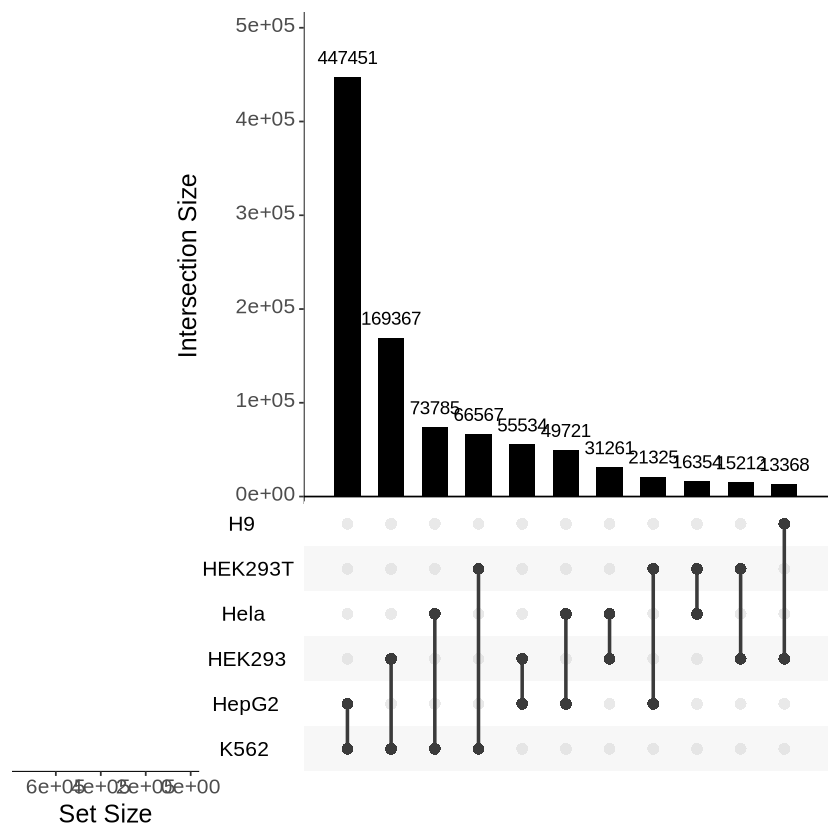

In [6]:
# Draw UpSet plot
g <- upset(
    upset_data,

    # Show all intersection bars (no limit)
    nintersects = NA,

    # Show up to 6 sets (matches your cell line list size)
    nsets = 6,

    # Set size bar color:
    # - NA means "use default"; you can also set a hex color if desired
    sets.bar.color = NA,

    # Main intersection bar color
    main.bar.color = "black",

    # Sort intersections by their frequency (count)
    order.by = "freq",
    decreasing = TRUE,

    # Relative height ratio: (main intersection bars, set size bars)
    mb.ratio = c(0.60, 0.40),

    # Scale text sizes (titles, labels, numbers) for readability
    text.scale = 1.8,

    # Aesthetics for the matrix dots/lines connecting sets
    point.size = 3.0,
    line.size = 1.0,

    # Keep intersection size labels horizontal (0 degrees)
    number.angles = 0
)
g
